# ESF interactive test notebook

Run this inside your `seismology` environment after `mamba activate seismology`.
It imports the reader from `richterpy.io.esf` and lets you inspect the parsed waveform.

In [1]:
import matplotlib.pyplot as plt

from pathlib import Path

from richterpy.io.esf import extract_esf, read_esf

repo_root = Path.cwd()
if repo_root.name == 'exploratory':
    repo_root = repo_root.parents[1]

In [2]:
channel_count = 4  # change to 4 if you want to test a 4-channel split
event_number="0001"
esf_path = repo_root / 'data' / 'm0013' / 'ESF' / '20250403' / f'20250403_{event_number}.ESF'
waveform, metadata = extract_esf(esf_path, channel_count=channel_count)
print(waveform.shape)
metadata

(65536, 4)


{'header_size_bytes': 32,
 'footer_offset_bytes': 2097184,
 'layout': {'channel_count': 4,
  'samples_per_channel': 65536,
  'header_size_bytes': 32,
  'channel_offsets_bytes': [32, 524320, 1048608, 1572896],
  'footer_offset_bytes': 2097184,
  'file_size_bytes': 2104030,
  'sample_dtype': '<f8'},
 'waveform_start_sample': 0,
 'waveform_end_sample': 65536,
 'waveform_samples': 65536,
 'payload_start_double': 4,
 'payload_end_double': 262148,
 'sample_rate': 10000000.0,
 'channel_count': 4,
 'samples_per_channel': 65536,
 'channel_offsets': [0.0, 0.0, 0.0, 0.0],
 'metadata_records': {'event_label': 'Data Streamed on 04/04/25',
  'event_stem': '20250403142840_1100877368',
  'event_component': '20250403',
  'event_clock': '142840',
  'channel_records': ['004S001007richter010Selvadurai',
   '004S002007richter010Selvadurai',
   '004S003007richter005Nardi',
   '004S004007richter005Nardi']}}

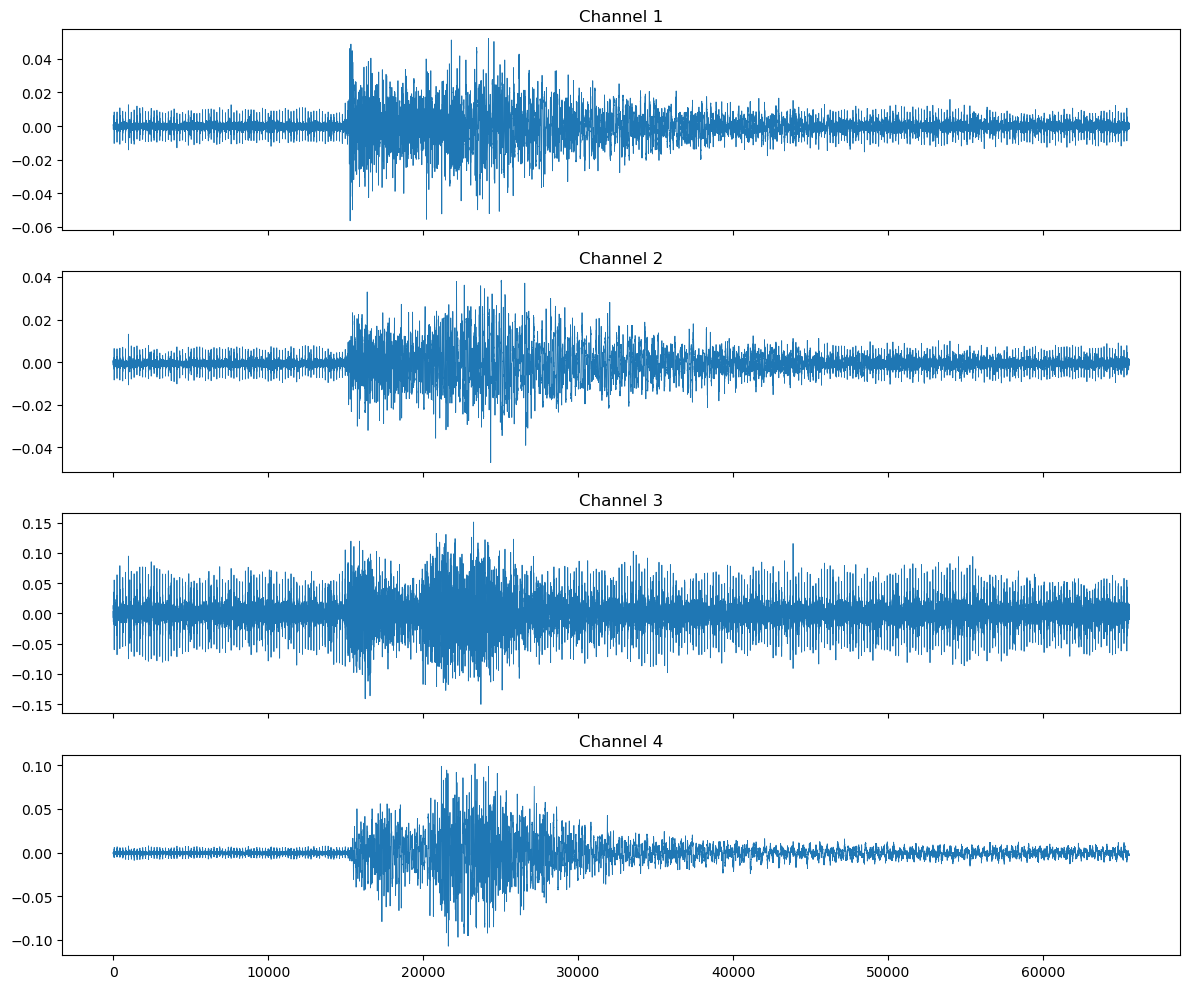

In [3]:
fig, axes = plt.subplots(channel_count, 1, sharex=True, figsize=(12, 2.5 * channel_count))
axes = [axes] if channel_count == 1 else list(axes)
for idx, ax in enumerate(axes):
    ax.plot(waveform[:, idx], lw=0.6)
    ax.set_title(f'Channel {idx + 1}')
plt.tight_layout()

In [4]:
stream, metadata = read_esf(repo_root / 'data' / 'm0013' / 'ESF' / '20250403' / '20250403_0144.ESF', channel_count=channel_count)
print(stream)
print(stream[0].stats)

4 Trace(s) in Stream:
.S01..CH1 | 2025-04-03T14:37:09.000000Z - 2025-04-03T14:37:09.006554Z | 10000000.0 Hz, 65536 samples
.S02..CH2 | 2025-04-03T14:37:09.000000Z - 2025-04-03T14:37:09.006554Z | 10000000.0 Hz, 65536 samples
.S03..CH3 | 2025-04-03T14:37:09.000000Z - 2025-04-03T14:37:09.006554Z | 10000000.0 Hz, 65536 samples
.S04..CH4 | 2025-04-03T14:37:09.000000Z - 2025-04-03T14:37:09.006554Z | 10000000.0 Hz, 65536 samples
         network: 
         station: S01
        location: 
         channel: CH1
       starttime: 2025-04-03T14:37:09.000000Z
         endtime: 2025-04-03T14:37:09.006554Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 65536
           calib: 1.0


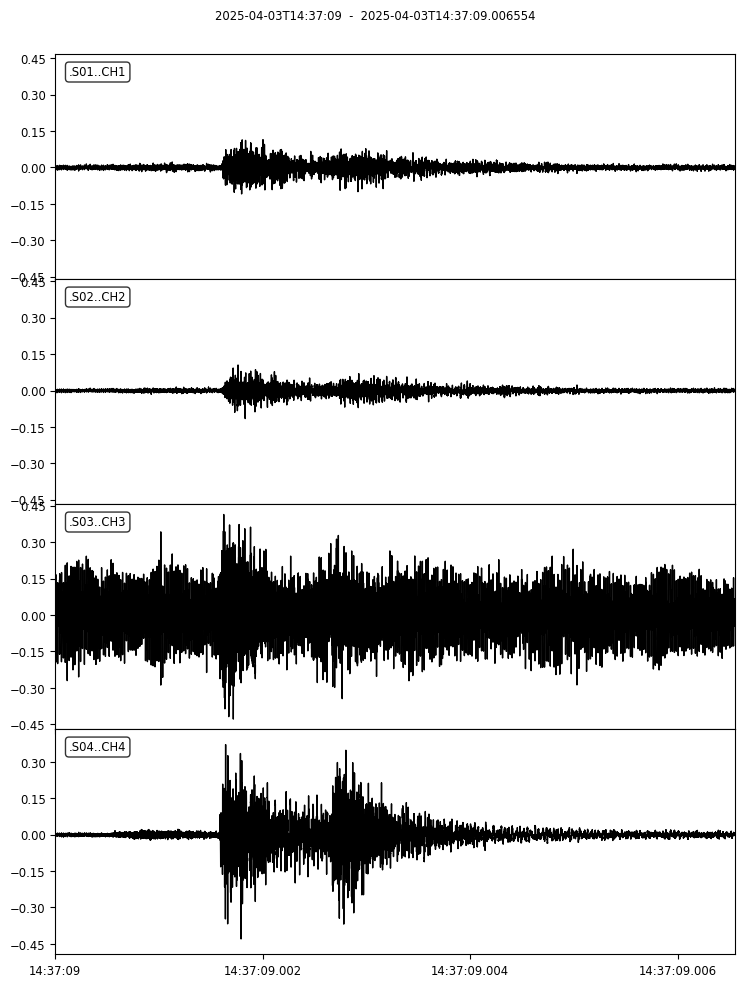

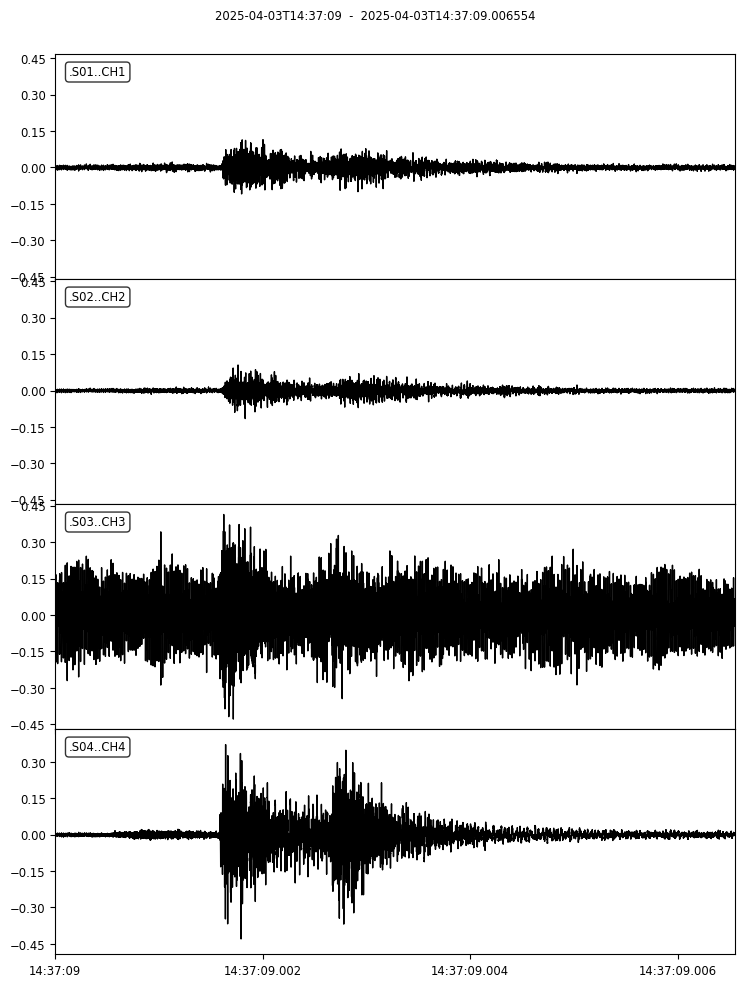

In [5]:
stream.plot()

In [6]:
metadata

{'header_size_bytes': 32,
 'footer_offset_bytes': 2097184,
 'layout': {'channel_count': 4,
  'samples_per_channel': 65536,
  'header_size_bytes': 32,
  'channel_offsets_bytes': [32, 524320, 1048608, 1572896],
  'footer_offset_bytes': 2097184,
  'file_size_bytes': 2104029,
  'sample_dtype': '<f8'},
 'waveform_start_sample': 0,
 'waveform_end_sample': 65536,
 'waveform_samples': 65536,
 'payload_start_double': 4,
 'payload_end_double': 262148,
 'sample_rate': 10000000.0,
 'channel_count': 4,
 'samples_per_channel': 65536,
 'channel_offsets': [0.0, 0.0, 0.0, 0.0],
 'metadata_records': {'event_label': 'Data Streamed on 04/04/25',
  'event_stem': '20250403143709_778581457',
  'event_component': '20250403',
  'event_clock': '143709',
  'channel_records': ['004S001007richter010Selvadurai',
   '004S002007richter010Selvadurai',
   '004S003007richter005Nardi',
   '004S004007richter005Nardi']}}